In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/skewed_dataset_300_rows.csv')

print(df.head())

    feature1   feature2  output
0   9.385362   0.530651       0
1  60.202429   7.579089       1
2  26.334914   7.779104       1
3  18.258851  10.145374       0
4   3.392497  12.949606       0


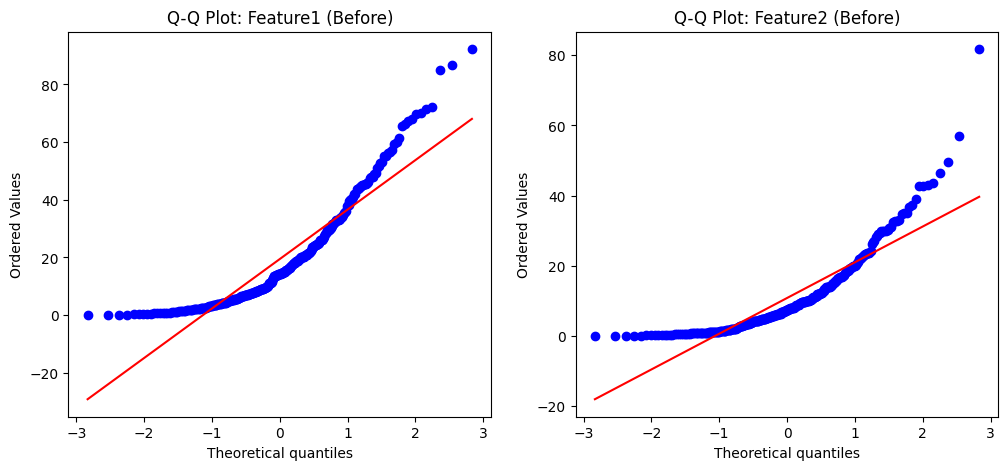

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
stats.probplot(df['feature1'], dist="norm", plot=plt)
plt.title("Q-Q Plot: Feature1 (Before)")

plt.subplot(1,2,2)
stats.probplot(df['feature2'], dist="norm", plot=plt)
plt.title("Q-Q Plot: Feature2 (Before)")

plt.show()

In [ ]:
X = df[['feature1', 'feature2']]
y = df['output']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_before = accuracy_score(y_test, y_pred)
print("Accuracy BEFORE transformation:", acc_before)

Accuracy BEFORE transformation: 0.9666666666666667


In [ ]:
df_transformed = df.copy()

df_transformed['feature1'] = np.log1p(df_transformed['feature1'])
df_transformed['feature2'] = np.log1p(df_transformed['feature2'])

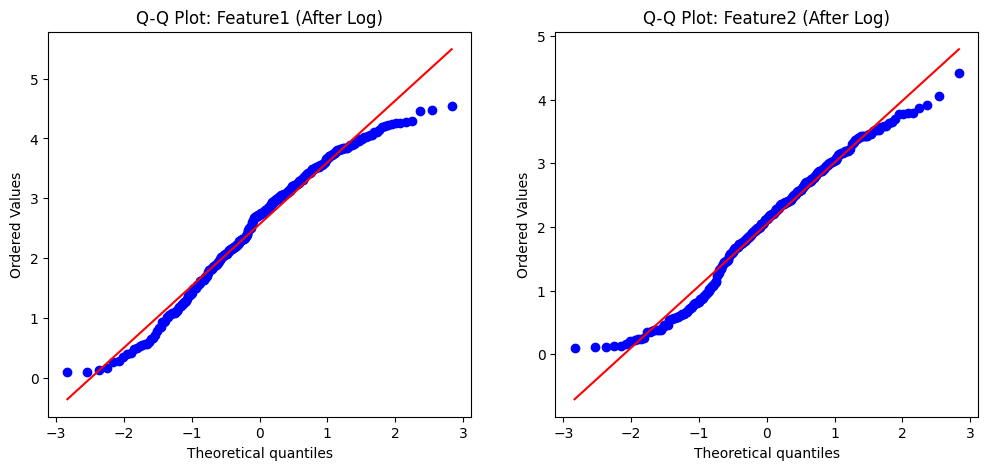

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
stats.probplot(df_transformed['feature1'], dist="norm", plot=plt)
plt.title("Q-Q Plot: Feature1 (After Log)")

plt.subplot(1,2,2)
stats.probplot(df_transformed['feature2'], dist="norm", plot=plt)
plt.title("Q-Q Plot: Feature2 (After Log)")

plt.show()

In [ ]:
X_t = df_transformed[['feature1', 'feature2']]
y_t = df_transformed['output']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42
)

In [ ]:
model_t = LogisticRegression()
model_t.fit(X_train_t, y_train_t)

y_pred_t = model_t.predict(X_test_t)

acc_after = accuracy_score(y_test_t, y_pred_t)
print("Accuracy AFTER transformation:", acc_after)

Accuracy AFTER transformation: 0.8166666666666667
